# SPOTIFY-AUDIO RECOMMENDATION SYSTEM.

## PROBLEM STATEMENT.


* Music streaming platform contain a large number of songs, making it difficult users to discover songs that match their personal preferences.
* This project aims to analyze users' songs preferences using audio features such as danceability,energy,acousticness,valance,tempo nd loudness and develop a system that can predict whether a user is a likely to enjoy a song and recommend songs with similar characteristics.

## AIM OF ANALYSIS.


* To investigate the relationsip between song audio features and user preferences in order to identify patterns that can be used to predict whether a user will like a song and recommend suitable songs.

### BUSINESS UNDERSTANDING

(a)What are the characteristics of the songs in the dataset?
(b)Which audio features are associated with the songs being liked?
(c)Which model predicts whether the song is liked?
(d)Can i recommend suggested songs with user preferences?

### DATA UNDERSTANDING.

* The dataset source is from [kaggle](https://www.kaggle.com/datasets/bricevergnou/spotify-recommendation)

* Danceability- how suitable a song is for dancing,from low to high
* Energy- how intense the song is
* key- music key of the song
* mode- major or minor music mode
* speechiness - amonut of spoken words in the song
* Acousticness - how acoustic the song sounds
* Instrumentalness - likelihood that the song contains little/no vocals
* Liveness - likelihood that the recoding sounds like a live performance.
* Valance- musical positivity/happiness of a song
* Tempo - speed of the song,measured in BPM.
* Duration_ms - song length in milliseconds
* time_signature - musical beats per measure
* liked - whether the user liked the song; 1= liked, 0= not liked


### DATA CLEANING.

In [3]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# load and read the dataset
df = pd.read_csv("Spotify.csv")
df.head()
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,0.636656,0.638431,5.497436,-9.481631,0.538462,0.148957,0.319093,0.192337,0.148455,0.493632,121.086174,213408.933333,3.912821,0.512821
std,0.216614,0.260096,3.415209,6.525086,0.499802,0.120414,0.320782,0.346226,0.105975,0.267695,28.084829,72152.392864,0.451332,0.501122
min,0.130000,0.002400,0.000000,-42.261000,0.000000,0.027800,0.000003,0.000000,0.033100,0.035300,60.171000,77203.000000,1.000000,0.000000
25%,0.462500,0.533500,2.000000,-9.962000,0.000000,0.056800,0.042200,0.000000,0.084000,0.269000,100.242000,178300.500000,4.000000,0.000000
50%,0.705000,0.659000,6.000000,-7.766000,1.000000,0.096200,0.213000,0.000008,0.105000,0.525000,124.896000,204000.000000,4.000000,1.000000
75%,0.799000,0.837500,8.000000,-5.829000,1.000000,0.230500,0.504000,0.097500,0.177000,0.717500,142.460500,242373.500000,4.000000,1.000000
max,0.946000,0.996000,11.000000,-2.336000,1.000000,0.540000,0.995000,0.969000,0.633000,0.980000,180.036000,655213.000000,5.000000,1.000000


In [5]:
# checking for null values
df.isnull().sum()

danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
liked               0
dtype: int64

In [6]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

### DATA VISUALIZATIONS

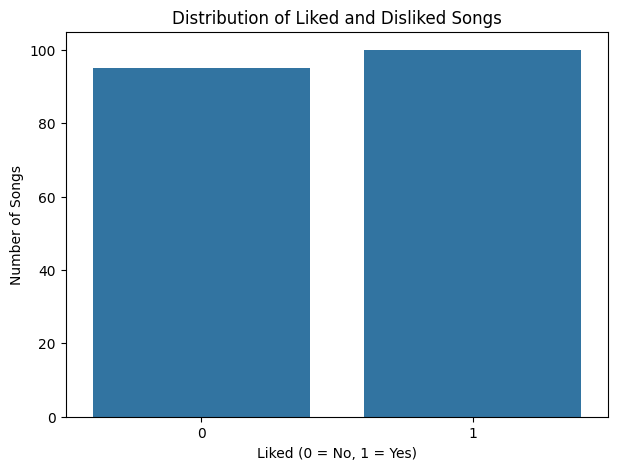

In [7]:
# LOTTING COUNTER PLOT FOR LIKED AND DISLIKED SONGS
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='liked')
plt.title('Distribution of Liked and Disliked Songs')
plt.xlabel('Liked (0 = No, 1 = Yes)')
plt.ylabel('Number of Songs')

plt.show()

### Findings
* 100 songs liked
* 95 songs not liked
* The target class is relatively balanced hence good for classification.

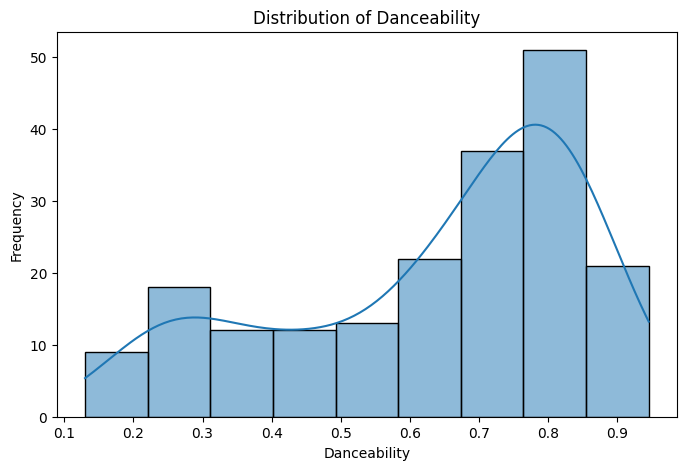

In [8]:
# checking the distribution of danceability
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='danceability', kde=True)
plt.title('Distribution of Danceability')
plt.xlabel('Danceability')
plt.ylabel('Frequency')

plt.show()


### Findings
* The distribution is negatively (left) skewed because most observations are concentrated at higher danceability vales while a smaller number tracks have low danceability.


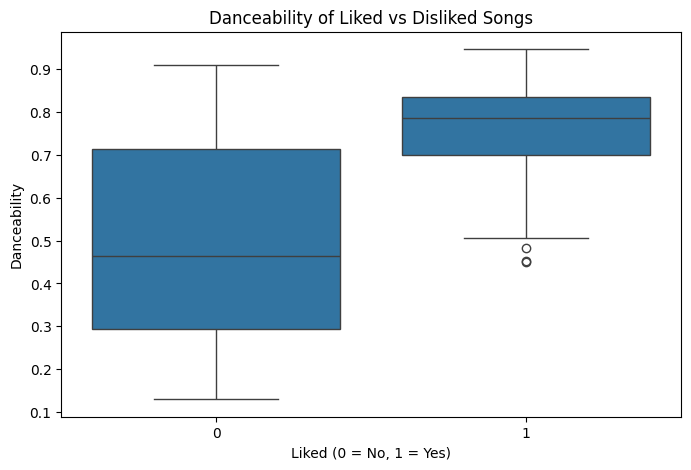

In [9]:
# checking the distribution of danceability for liked and disliked songs
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='liked', y='danceability')
plt.title('Danceability of Liked vs Disliked Songs')
plt.xlabel('Liked (0 = No, 1 = Yes)')
plt.ylabel('Danceability')

plt.show()

### Findings
* Liked songs(1) have a much higher median danceability of approximately 0.82.
* Dislike songs have a much wider spread ranging from 0.15 to 0.92 indicating greater variation in the danceability of songs users didn't like.

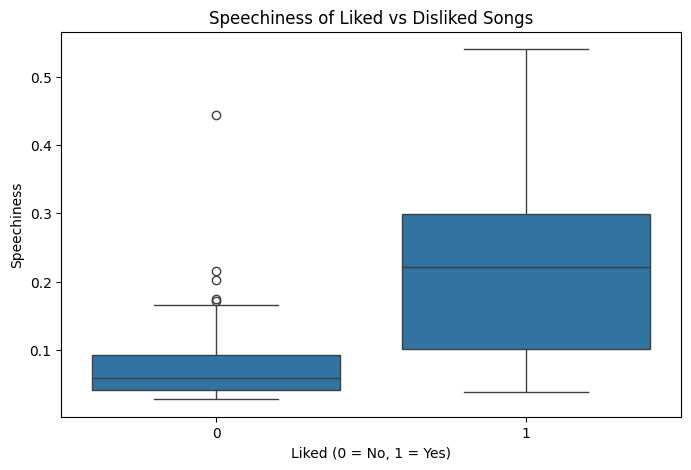

In [10]:
# checking the distribution of speechiness
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='liked', y='speechiness')
plt.title('Speechiness of Liked vs Disliked Songs')
plt.xlabel('Liked (0 = No, 1 = Yes)')
plt.ylabel('Speechiness')

plt.show()

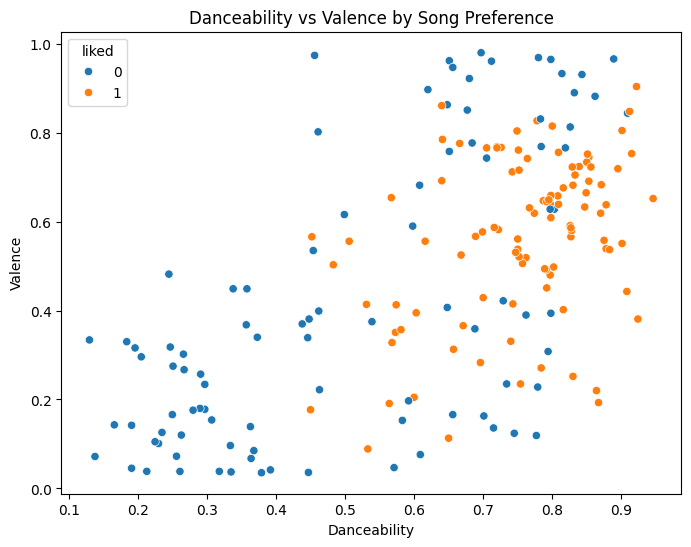

In [11]:
# checking the relationship between danceability and valence
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='danceability',
    y='valence',
    hue='liked'
)

plt.title('Danceability vs Valence by Song Preference')
plt.xlabel('Danceability')
plt.ylabel('Valence')

plt.show()

### Findings
* The scatter plot indicates a positive relationship between danceability and valence. Liked songs tend to be concentrated at higher danceability and moderate-to-high valence levels, although there is considerable overlap between liked and disliked songs.
* This suggests that danceability and valence may contribute to predicting song preference but are not sufficient on their own.

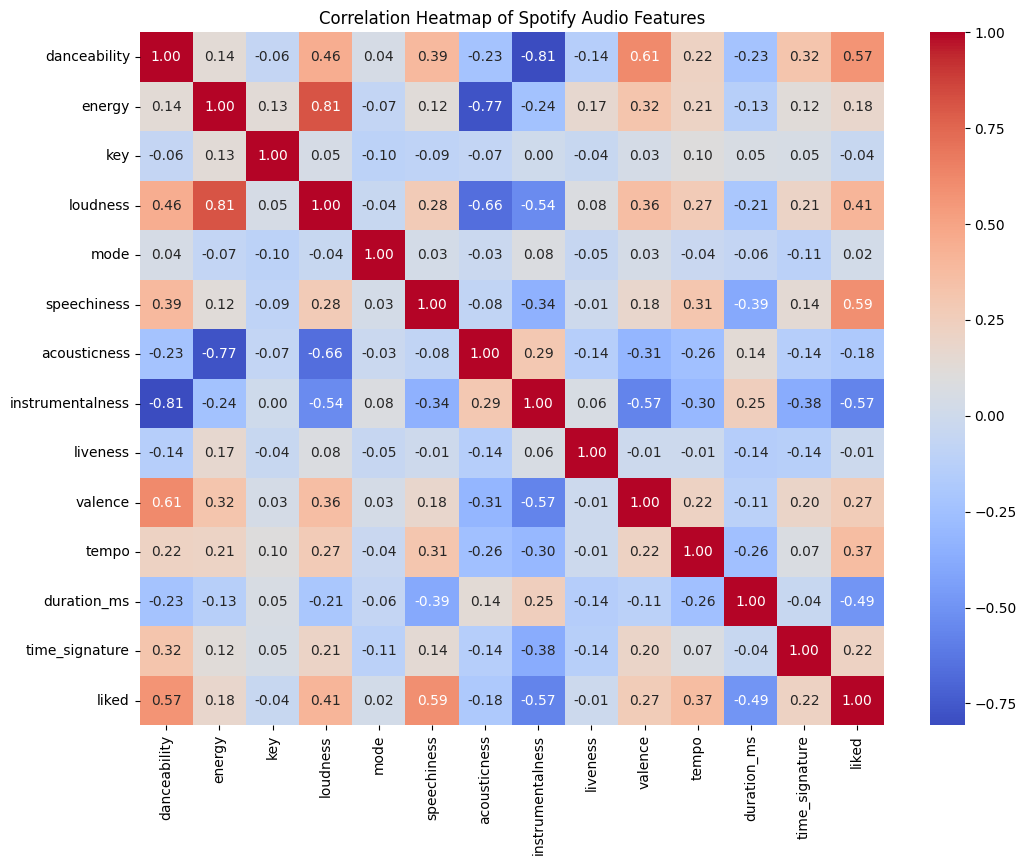

In [12]:

# correlation heatmap of the audio features
plt.figure(figsize=(12,9))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Spotify Audio Features')

plt.show()

* The strongest relationship are:
* Speechiness - liked
* Danceability - liked
* Loudness -liked
* The strongest negative relationship are:
* Instrumentalness - liked
* Duration - liked

## MODEL AND RECOMMEND.

In [13]:
import pandas as pd
import numpy as np

In [14]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "key",
    "mode",
    "time_signature"
]

X = df[features].copy()

X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,key,mode,time_signature
0,0.803,0.6240,-6.764,0.0477,0.451,0.000734,0.1000,0.6280,95.968,304524,7,0,4
1,0.762,0.7030,-7.951,0.3060,0.206,0.000000,0.0912,0.5190,151.329,247178,10,0,4
2,0.261,0.0149,-27.528,0.0419,0.992,0.897000,0.1020,0.0382,75.296,286987,1,1,4
3,0.722,0.7360,-6.994,0.0585,0.431,0.000001,0.1230,0.5820,89.860,208920,3,0,4
4,0.787,0.5720,-7.516,0.2220,0.145,0.000000,0.0753,0.6470,155.117,179413,1,1,4


In [16]:
#scaling the features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [17]:
# calculate cosine similarity between songs
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(X_scaled)
print(similarity_matrix.shape)
  

(195, 195)


In [ ]:
# create function to recommend songs.
def recommend_songs(song_index, num_recommendations=5):
    similarity_scores = list(enumerate(similarity_matrix[song_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:num_recommendations+1]
    recommended_indices = [i[0] for i in similarity_scores]
    return df.iloc[recommended_indices] 


In [19]:
#testing the recommendation system.
recommend_songs(0,5)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
184,0.762,0.600,5,-7.585,0,0.0909,0.542,0.000000,0.0841,0.390,115.908,352627,4,0
105,0.819,0.811,6,-7.760,0,0.0349,0.203,0.005580,0.1390,0.766,106.684,246760,4,0
154,0.688,0.569,10,-7.007,0,0.0375,0.392,0.000175,0.1200,0.359,109.041,252373,4,0
36,0.784,0.700,7,-7.649,0,0.1080,0.491,0.000000,0.1080,0.769,82.028,190067,4,0
180,0.797,0.468,2,-9.280,0,0.0278,0.600,0.000030,0.0623,0.628,108.628,248440,4,0


In [20]:
#show similarity scores too
def recommend_songs(song_index, num_recommendations=5):
    similarity_scores = list(enumerate(similarity_matrix[song_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    recommendations = similarity_scores[1:num_recommendations+1]
    result = df.iloc[[i[0] for i in recommendations]].copy()
    result['similarity_score'] = [i[1] for i in recommendations]
    return result


In [21]:
recommend_songs(0,5)


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked,similarity_score
184,0.762,0.600,5,-7.585,0,0.0909,0.542,0.000000,0.0841,0.390,115.908,352627,4,0,0.820946
105,0.819,0.811,6,-7.760,0,0.0349,0.203,0.005580,0.1390,0.766,106.684,246760,4,0,0.790886
154,0.688,0.569,10,-7.007,0,0.0375,0.392,0.000175,0.1200,0.359,109.041,252373,4,0,0.746578
36,0.784,0.700,7,-7.649,0,0.1080,0.491,0.000000,0.1080,0.769,82.028,190067,4,0,0.718118
180,0.797,0.468,2,-9.280,0,0.0278,0.600,0.000030,0.0623,0.628,108.628,248440,4,0,0.702524


In [30]:
# create user's profile
user_profile = X_scaled[liked_indices].mean(axis=0)

In [31]:
# compare the user's profile with all songs in the dataset
user_similarity_scores = cosine_similarity([user_profile], X_scaled)[0]

In [23]:
# recommend song based on liked songs
liked_songs_indices = df[df['liked'] == 1]
print(liked_songs_indices)

     danceability  energy  key  loudness  mode  speechiness  acousticness  \
1           0.762   0.703   10    -7.951     0       0.3060        0.2060   
3           0.722   0.736    3    -6.994     0       0.0585        0.4310   
4           0.787   0.572    1    -7.516     1       0.2220        0.1450   
5           0.778   0.632    8    -6.415     1       0.1250        0.0404   
6           0.666   0.589    0    -8.405     0       0.3240        0.5550   
..            ...     ...  ...       ...   ...          ...           ...   
186         0.533   0.593   11    -5.284     1       0.0581        0.1560   
187         0.864   0.629    1    -6.602     0       0.2790        0.0987   
188         0.856   0.602    0    -8.173     0       0.3360        0.1270   
193         0.574   0.729   10    -5.838     0       0.0965        0.0406   
194         0.747   0.666   11    -7.845     1       0.1970        0.1300   

     instrumentalness  liveness  valence    tempo  duration_ms  \
1        

In [24]:
#get their indexes
liked_indices = df.index[df["liked"] ==1].tolist()
print(liked_indices)

[1, 3, 4, 5, 6, 7, 9, 11, 13, 14, 16, 18, 19, 20, 22, 23, 25, 26, 27, 28, 29, 30, 31, 33, 39, 41, 42, 43, 47, 50, 51, 52, 55, 56, 57, 61, 63, 65, 66, 68, 69, 70, 71, 72, 77, 78, 79, 80, 82, 84, 90, 94, 96, 98, 99, 101, 102, 104, 109, 111, 112, 118, 119, 120, 122, 123, 124, 125, 133, 134, 136, 139, 140, 141, 147, 148, 149, 150, 152, 155, 156, 160, 161, 162, 163, 165, 166, 169, 172, 173, 177, 178, 179, 181, 182, 186, 187, 188, 193, 194]


In [25]:
#recommend based on all the songs the user liked.
liked_indices = df.index[df["liked"] == 1].tolist()
user_profile = X_scaled[liked_indices].mean(axis=0)
user_similarity_scores = cosine_similarity([user_profile], X_scaled)[0]
recommendation_indices = np.argsort(user_similarity_scores)[::-1]



In [26]:
# remove songs that the user already liked.
recommendation_indices = [i for i in recommendation_indices if i not in liked_indices]

In [27]:
#Get the top 10 recommended songs
top_10 = recommendation_indices[:10]
recommendations = df.iloc[top_10]
recommendations["similarity_score"] = user_similarity_scores[top_10]
recommendations

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked,similarity_score
24,0.729,0.533,9,-10.104,0,0.4440,0.7470,0.000005,0.0848,0.422,155.999,225953,4,0,0.413553
130,0.909,0.582,7,-5.357,1,0.0665,0.0696,0.000048,0.0984,0.844,126.063,249598,4,0,0.354559
164,0.889,0.646,7,-6.366,1,0.0668,0.1950,0.000032,0.0502,0.966,110.842,213427,4,0,0.339350
74,0.539,0.487,1,-9.653,1,0.2020,0.3090,0.000000,0.0970,0.375,169.985,186353,4,0,0.296201
73,0.843,0.656,1,-11.184,1,0.0595,0.0466,0.018700,0.1690,0.931,121.112,215653,4,0,0.268916
46,0.826,0.760,11,-6.382,0,0.1170,0.3920,0.000000,0.1320,0.813,99.974,216285,4,0,0.240214
145,0.651,0.639,3,-7.836,0,0.0583,0.0190,0.000000,0.0522,0.758,157.738,247440,4,0,0.213293
121,0.697,0.809,9,-8.197,1,0.0302,0.1140,0.000521,0.1830,0.980,125.941,214827,4,0,0.209357
191,0.862,0.624,3,-11.630,1,0.0565,0.0192,0.000153,0.0465,0.882,124.896,254240,4,0,0.203459
143,0.461,0.918,4,-8.507,1,0.0959,0.4050,0.000330,0.1260,0.802,172.435,249960,4,0,0.162423


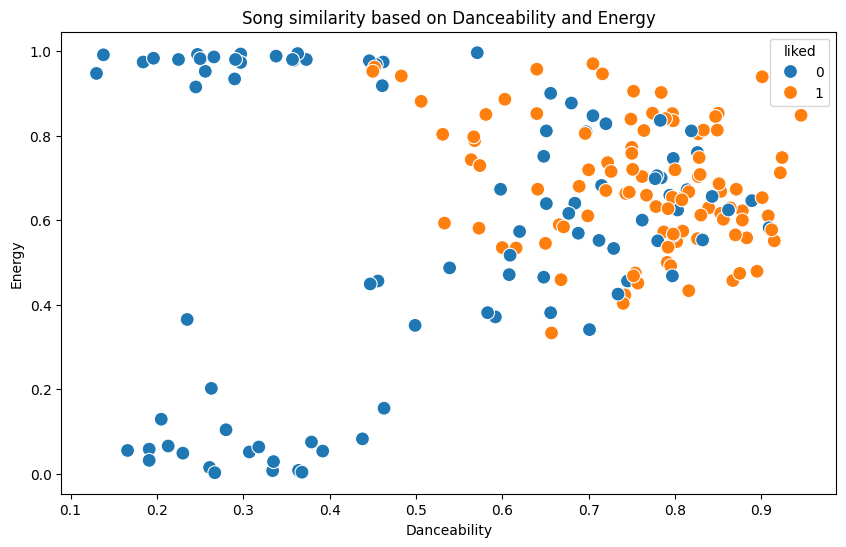

In [29]:
# visualize the recommendations.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='danceability', y='energy', hue='liked', s=100)
plt.title("Song similarity based on Danceability and Energy")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.show()

* liked songs tend to have a higher danceability(0.7 -0.9) and modarate to high energy.
* Disliked songs are more widely distributed( blue)
* Low danceability and low energy are strongly associated with disliked songs
     * 0.15-0.4 dancability
     * 0-0.2 energy
